Import relevant libraries. Libraries are downloaded in a virtual environment. Make sure interpreter is in the virtual
environment (.venv (Python ...)).

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("Working environment ready.")

Working environment ready.


Load QQQ data.

In [2]:
ticker = 'QQQ'

qqq = yf.download(
    ticker,
    start='2010-01-01',
    end='2026-01-01',
    auto_adjust=True,
)

qqq.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,QQQ,QQQ,QQQ,QQQ,QQQ
Date,,,,,
2010-01-04,40.290791,40.351551,40.160598,40.212677,62822800
2010-01-05,40.290791,40.360229,40.065122,40.264753,62935600
2010-01-06,40.047749,40.403613,39.986992,40.273420,96033000
2010-01-07,40.073792,40.160590,39.856801,40.108511,77094100
2010-01-08,40.403614,40.403614,39.865479,39.986993,88886600


Retrieve price data, and look at its structure.

In [5]:
prices = qqq[['Close']].copy()
prices = prices.rename(columns={'Close': 'QQQ_close'})

prices.head()

Price,QQQ_close
Ticker,QQQ
Date,
2010-01-04,40.290791
2010-01-05,40.290791
2010-01-06,40.047749
2010-01-07,40.073792
2010-01-08,40.403614


Compute log returns.

In [6]:
prices['QQQ_log_return'] = np.log(prices['QQQ_close'] / prices['QQQ_close'].shift(1))

returns = prices['QQQ_log_return'].dropna()

returns.head()

Date
2010-01-05    0.000000
2010-01-06   -0.006050
2010-01-07    0.000650
2010-01-08    0.008197
2010-01-11   -0.004089
Name: QQQ_log_return, dtype: float64

Plot closing price.

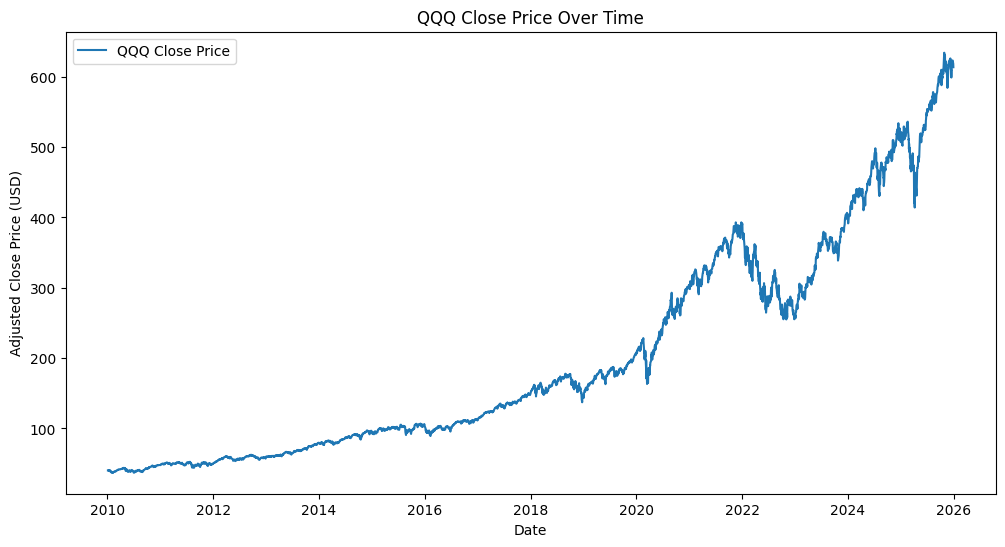

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(prices.index, prices['QQQ_close'], label='QQQ Close Price')
ax.set_title('QQQ Close Price Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Adjusted Close Price (USD)')
ax.legend()
plt.show()

Plot log returns.

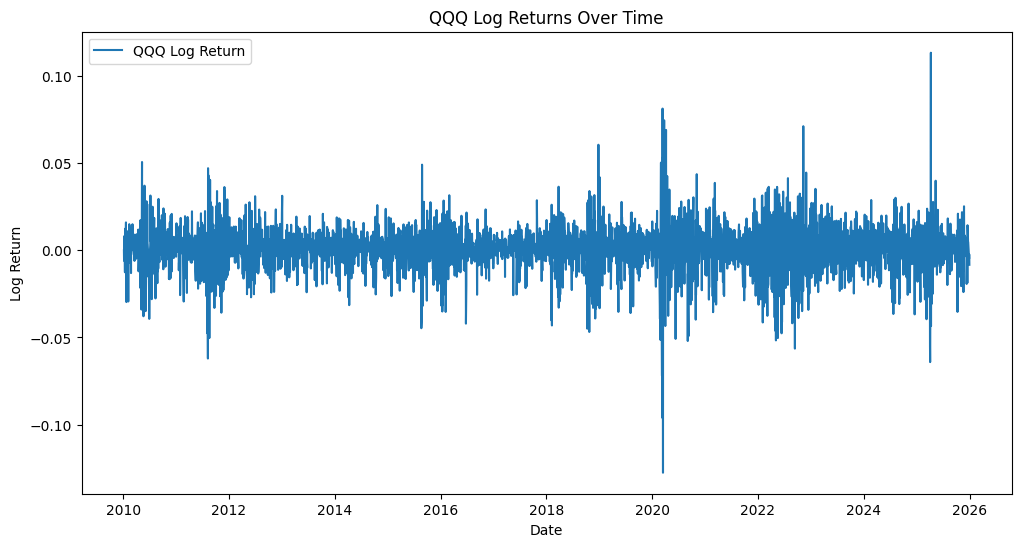

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(returns.index, returns, label='QQQ Log Return')
ax.set_title('QQQ Log Returns Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Log Return')
ax.legend()
plt.show()

Over the 10-year period, QQQ shows a clear upward trend in adjusted close price, while daily log returns fluctuate substantially around zero. This highlights the difference between long-run cumulative growth and short-run return volatility.

The return series also appears to show periods of higher and lower volatility, suggesting volatility clustering rather than constant variance through time - motivates models like GARCH, stochastic volatility or Bayesian time-series models.

Summary statistics are below.

In [14]:
summary_stats = returns.describe()

print(f"Summary Statistics: \n{summary_stats}")
print(f"\nMean daily returns: {returns.mean()}")
print(f"\nDaily volatility: {returns.std()}")
print(f"\nAnnualised volatility: {returns.std() * np.sqrt(252)}")
print(f"\nSkewness: {returns.skew()}")
print(f"\nKurtosis: {returns.kurtosis()}")

Summary Statistics: 
count    4023.000000
mean        0.000677
std         0.013022
min        -0.127592
25%        -0.004733
50%         0.001196
75%         0.007324
max         0.113356
Name: QQQ_log_return, dtype: float64

Mean daily returns: 0.0006768870583719168

Daily volatility: 0.013022108625316005

Annualised volatility: 0.20671956580953202

Skewness: -0.3897228687980343

Kurtosis: 7.469603367999316


Compute and plot rolling volatility over a 30 day window.

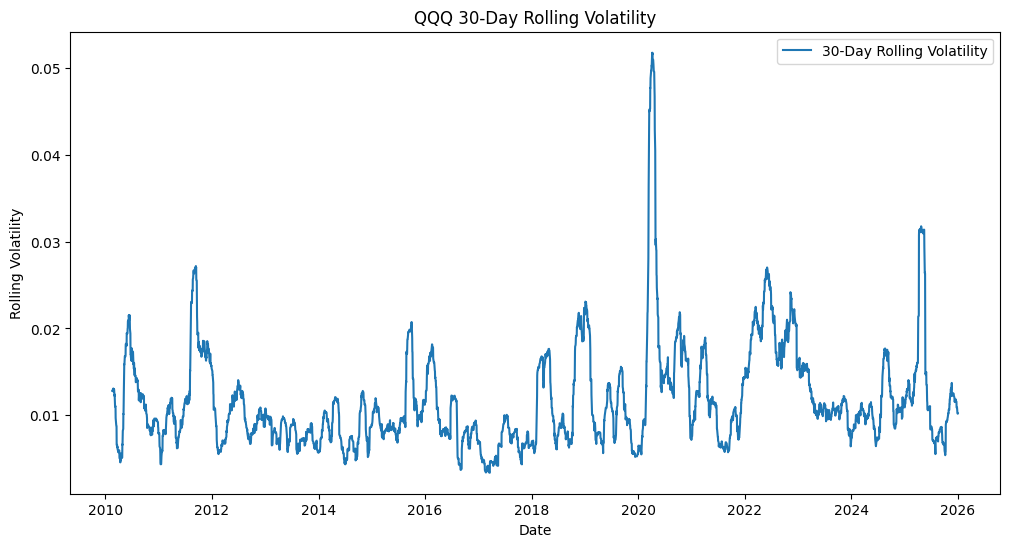

In [15]:
rolling_volatility = returns.rolling(window=30).std()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(rolling_volatility.index, rolling_volatility, label='30-Day Rolling Volatility')
ax.set_title('QQQ 30-Day Rolling Volatility')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Volatility')
ax.legend()
plt.show()

Rolling volatility highlights non-linear volatility over time. Returns are not Gaussian.